In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearbRegression
from sklearn.metrics import mean_squared_error
import eli5

ImportError: cannot import name 'Memory' from 'joblib' (unknown location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 23.5 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]━━━ 7/8 [seaborn]ib]


In [8]:
!pip install pandas==1.4.2

In [6]:
!conda update pandas numpy


Solving environment: / 

Updating pandas is constricted by 

anaconda -> requires pandas==1.4.2=py39h295c915_0

If you are sure you want an update of your package either try `conda update --all` or install a specific version of the package you want using `conda install <pkg>=<version>`



Updating numpy is constricted by 

anaconda -> requires numpy==1.21.5=py39he7a7128_1

If you are sure you want an update of your package either try `conda update --all` or install a specific version of the package you want using `conda install <pkg>=<version>`

done


==> WARNING: A newer version of conda exists. <==
  current version: 4.12.0
  latest version: 25.3.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/codespace/anaconda3

  added / updated specs:
    - numpy
    - pandas


The following packages will be downloaded:

    package                    |            build
    ---------------------------|----------

In [ ]:
def

In [2]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')

In [3]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.5,0.5,0.5,0.00,0.0,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.0,0.5,0.5,2.81,0.0,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.0,0.5,0.5,1.00,0.0,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.0,0.5,0.5,0.00,0.0,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.0,0.0,-0.5,0.00,0.0,None,-0.3,-52.80,3.0,1.0,0.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               76518 non-null  int64         
 1   lpep_pickup_datetime   76518 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  76518 non-null  datetime64[ns]
 3   store_and_fwd_flag     40471 non-null  object        
 4   RatecodeID             40471 non-null  float64       
 5   PULocationID           76518 non-null  int64         
 6   DOLocationID           76518 non-null  int64         
 7   passenger_count        40471 non-null  float64       
 8   trip_distance          76518 non-null  float64       
 9   fare_amount            76518 non-null  float64       
 10  extra                  76518 non-null  float64       
 11  mta_tax                76518 non-null  float64       
 12  tip_amount             76518 non-null  float64       
 13  t

In [5]:
df['duration'] = pd.to_datetime(df['lpep_dropoff_datetime'])  - pd.to_datetime(df['lpep_pickup_datetime'])

In [8]:
df['duration'] = df['duration'].dt.total_seconds()

In [9]:
df['duration'] = df['duration']/60

In [10]:
df['duration'] 

0         3.933333
1         8.750000
2         5.966667
3         7.083333
4         0.066667
           ...    
76513    38.000000
76514    38.000000
76515    11.000000
76516    27.000000
76517    10.000000
Name: duration, Length: 76518, dtype: float64

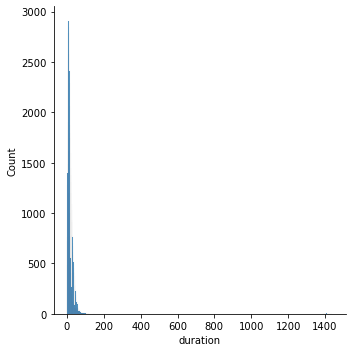

In [12]:
sns.displot(df['duration'])

In [13]:
df['duration'].describe()

count    76518.000000
mean        19.927896
std         59.338594
min          0.000000
25%          8.000000
50%         13.883333
75%         23.000000
max       1439.600000
Name: duration, dtype: float64

In [14]:
## focus on duration>=1 and duration<=60
df = df[(df['duration']>=1)&(df['duration']<=60)].reset_index(drop = True)

In [15]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
4,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.50,...,0.5,0.96,0.00,None,0.3,5.76,1.0,1.0,0.00,2.316667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73903,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
73904,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
73905,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
73906,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73908 entries, 0 to 73907
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               73908 non-null  int64         
 1   lpep_pickup_datetime   73908 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  73908 non-null  datetime64[ns]
 3   store_and_fwd_flag     38175 non-null  object        
 4   RatecodeID             38175 non-null  float64       
 5   PULocationID           73908 non-null  int64         
 6   DOLocationID           73908 non-null  int64         
 7   passenger_count        38175 non-null  float64       
 8   trip_distance          73908 non-null  float64       
 9   fare_amount            73908 non-null  float64       
 10  extra                  73908 non-null  float64       
 11  mta_tax                73908 non-null  float64       
 12  tip_amount             73908 non-null  float64       
 13  t

In [74]:
df['trip_type'].unique(),df['payment_type'].unique(), df['VendorID'].unique()

(array(['1.0', '2.0', 'unknown'], dtype=object),
 array(['2.0', '1.0', '3.0', '4.0', '5.0', 'unknown'], dtype=object),
 array([2, 1]))

In [59]:
df['trip_type'].fillna("unknown", inplace=True)
df['payment_type'].fillna("unknown", inplace=True)


In [98]:
df['passenger_count'].fillna(-1, inplace=True)

In [139]:
df['PU_DO'] = df['DOLocationID'] + '_' + df['PULocationID']

In [140]:
categorical = ['PU_DO','trip_type','payment_type','VendorID'] #['PULocationID','DOLocationID','trip_type','payment_type','VendorID']
numerical= ['trip_distance','passenger_count','fare_amount']

In [141]:
df[categorical] = df[categorical].astype(str)

In [142]:
train_dicts= df[categorical + numerical].to_dict(orient = 'records')

In [143]:
train_dicts

[{'PU_DO': '151_43',
  'trip_type': '1.0',
  'payment_type': '2.0',
  'VendorID': '2',
  'trip_distance': 1.01,
  'passenger_count': 1.0,
  'fare_amount': 5.5},
 {'PU_DO': '239_166',
  'trip_type': '1.0',
  'payment_type': '1.0',
  'VendorID': '2',
  'trip_distance': 2.53,
  'passenger_count': 1.0,
  'fare_amount': 10.0},
 {'PU_DO': '42_41',
  'trip_type': '1.0',
  'payment_type': '1.0',
  'VendorID': '2',
  'trip_distance': 1.12,
  'passenger_count': 1.0,
  'fare_amount': 6.0},
 {'PU_DO': '75_168',
  'trip_type': '1.0',
  'payment_type': '2.0',
  'VendorID': '2',
  'trip_distance': 1.99,
  'passenger_count': 1.0,
  'fare_amount': 8.0},
 {'PU_DO': '75_75',
  'trip_type': '1.0',
  'payment_type': '1.0',
  'VendorID': '2',
  'trip_distance': 0.45,
  'passenger_count': 6.0,
  'fare_amount': 3.5},
 {'PU_DO': '265_225',
  'trip_type': '1.0',
  'payment_type': '1.0',
  'VendorID': '2',
  'trip_distance': 12.19,
  'passenger_count': 1.0,
  'fare_amount': 38.0},
 {'PU_DO': '244_244',
  'trip_t

In [144]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [148]:
target = 'duration'
y_train = df[target].values

In [149]:
y_train

array([ 3.93333333,  8.75      ,  5.96666667, ..., 11.        ,
       27.        , 10.        ])

In [151]:
## model
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [152]:
y_pred = lr.predict(X_train)

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


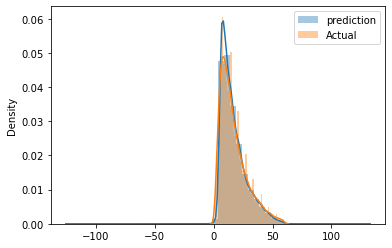

In [153]:
sns.distplot(y_pred,label="prediction")
sns.distplot(y,label ="Actual")

plt.legend()

In [154]:
mean_squared_error(y,y_pred, squared= False)

4.2478031075484655

In [155]:
np.sqrt(np.mean((y-y_mean)**2))

11.56308481453456

In [156]:
## R1 score
y_mean = y.mean()
r2_score = 1 - (np.sum((y-y_pred)**2)/(np.sum((y-y_mean)**2)))


In [157]:
r2_score

0.8650473757196349

## Validation Dataset

In [ ]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')

## Model Explainability

## Permutaion Importance
Which feature is most import when we do prediction

In [ ]:
## slightly better than mean
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(lr, random_state=1).fit(X_train.toarray(), y)

# Feature importance दिखाएं
eli5.show_weights(perm, feature_names=dv.get_feature_names_out())

## Partial Plots
How prediction varies with features

['DOLocationID=1', 'DOLocationID=10', 'DOLocationID=100', 'DOLocationID=101', 'DOLocationID=102', 'DOLocationID=106', 'DOLocationID=107', 'DOLocationID=108', 'DOLocationID=109', 'DOLocationID=11', 'DOLocationID=111', 'DOLocationID=112', 'DOLocationID=113', 'DOLocationID=114', 'DOLocationID=115', 'DOLocationID=116', 'DOLocationID=117', 'DOLocationID=118', 'DOLocationID=119', 'DOLocationID=12', 'DOLocationID=120', 'DOLocationID=121', 'DOLocationID=122', 'DOLocationID=123', 'DOLocationID=124', 'DOLocationID=125', 'DOLocationID=126', 'DOLocationID=127', 'DOLocationID=128', 'DOLocationID=129', 'DOLocationID=13', 'DOLocationID=130', 'DOLocationID=131', 'DOLocationID=132', 'DOLocationID=133', 'DOLocationID=134', 'DOLocationID=135', 'DOLocationID=136', 'DOLocationID=137', 'DOLocationID=138', 'DOLocationID=139', 'DOLocationID=14', 'DOLocationID=140', 'DOLocationID=141', 'DOLocationID=142', 'DOLocationID=143', 'DOLocationID=144', 'DOLocationID=145', 'DOLocationID=146', 'DOLocationID=147', 'DOLoc

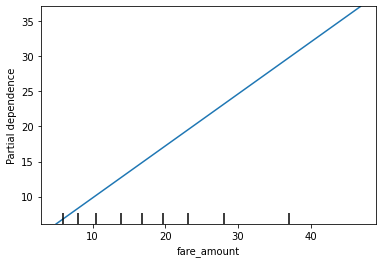

In [138]:

from sklearn.inspection import PartialDependenceDisplay

# Check exact feature name
print(dv.feature_names_)  # or dv.get_feature_names_out() for newer sklearn

# Then use the correct name if it's there, e.g.:
disp1 = PartialDependenceDisplay.from_estimator(
    lr,
    X_train.toarray(),
    ['fare_amount'],  # replace this with the exact name found above
    feature_names=dv.feature_names_  # pass actual feature names here
)
plt.show()

## fare amount us kind of directly impact duration

## SHAP

In [ ]:
conda remove pandas numpy
conda install pandas numpy
